In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from jinja2.sandbox import MAX_RANGE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

# Task 1 - Baseline Study

### Task 1.1 - Data preparation and validation pipeline 

**Concrete Segmentation Question (RQ1)**

RQ1: "Are there natural, distinct segments of guests that differentiate short-stay individual/business travelers from long-stay family or leisure groups based on their group composition and weekend/weekday stay patterns?"

**Unit of Analysis**

Unit of Analysis: A single hotel booking.

**Short Data Documentation**

Source: The "Hotel Booking Demand" dataset, originally published by António, de Almeida, and Nunes (2019). It contains real-world Property Management System (PMS) data from two hotels in Portugal: a Resort Hotel (Algarve) and a City Hotel (Lisbon). We are using the specific course release version (hotel_bookings_course_release_v1.csv).

License/Terms: The dataset is open and provided for academic/educational purposes, with identifiers removed or anonymized as documented in the original reference paper.

What each row represents: Each row corresponds to one individual booking (regardless of whether the booking ultimately arrived or was canceled).

Time Span: The data covers bookings with arrival dates spanning from July 1, 2015, to August 31, 2017.

Known Data Quality Issues: 
1. Missing Values: There is a minor missingness issue in the children attribute (4 missing records).
2. Extreme Outliers: The exploratory data analysis (EDA) revealed severe outliers in numerical variables (e.g., a maximum of 55 adults in a single booking, and up to 50 stays_in_week_nights). These represent a significant quality issue for distance-based clustering (like K-Means) and require heuristic filtering before standardization.
3. Information Leakage: The dataset includes post-booking/outcome variables (such as is_canceled and reservation_status) that act as "leakage" and must be strictly excluded from the feature set used to train the unsupervised models.

In [2]:
df = pd.read_csv('hotel_bookings_course_release_v1.csv')

print(f"Initial dataset dimensions: {df.shape[0]} rows and {df.shape[1]} columns.\n")

Initial dataset dimensions: 119390 rows and 32 columns.



In [3]:
# LEAKEGE CONTROL

num_features = ['adults', 'children', 'babies', 'stays_in_weekend_nights', 'stays_in_week_nights','lead_time']
cat_features = ['hotel','arrival_date_month','market_segment']

df_analysis = df[num_features + cat_features].copy()

In [4]:
# ANALYSIS AND REPORTS

print("--- Missing Values Report ---")
missing_report = df_analysis.isnull().sum()

if missing_report.any():
    print(missing_report[missing_report > 0])
else:
    print("No missing values detected.")

print("\n--- Outliers Report ---")
desc_stats = df_analysis[num_features].describe()
print(desc_stats.loc[['min', '50%', '75%', 'max']])
print("\nConclusion: Extreme outliers are observed in the numeric features above. "
      "These require careful treatment because KMeans is sensitive to scale and large values.")

--- Missing Values Report ---
children    4
dtype: int64

--- Outliers Report ---
     adults  children  babies  stays_in_weekend_nights  stays_in_week_nights  \
min     0.0       0.0     0.0                      0.0                   0.0   
50%     2.0       0.0     0.0                      1.0                   2.0   
75%     2.0       0.0     0.0                      2.0                   3.0   
max    55.0      10.0    10.0                     19.0                  50.0   

     lead_time  
min        0.0  
50%       69.0  
75%      160.0  
max      737.0  

Conclusion: Extreme outliers are observed in the numeric features above. These require careful treatment because KMeans is sensitive to scale and large values.


In [5]:
# OUTLIER TREATMENT (Heuristic Filter)
print("--- Removal of Extreme Outliers ---")
# We apply a common-sense (domain) filter to avoid distorting the centroids in K-Means
adults_filter = df_analysis['adults'] <= 10
nights_filter = df_analysis['stays_in_week_nights'] <= 20
babies_filter = df_analysis['babies'] <= 5

df_clean = df_analysis[adults_filter & nights_filter & babies_filter].copy()

removed_outliers = len(df_analysis) - len(df_clean)
print(f"{removed_outliers} anomalous bookings were removed.")
print(f"Clean dataset ready for the Pipeline: {len(df_clean)} rows.\n")


--- Removal of Extreme Outliers ---
60 anomalous bookings were removed.
Clean dataset ready for the Pipeline: 119330 rows.



In [6]:

feature_sets = {
    'with_hotel': {
        'num_features': num_features,
        'cat_features': ['hotel', 'arrival_date_month', 'market_segment']
    },
    'without_hotel': {
        'num_features': num_features,
        'cat_features': ['arrival_date_month', 'market_segment']
    }
}

k_range = range(3, 7)

# Numerical Pipeline: Median imputation + standard scaling
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical Pipeline: Mode imputation + one-hot encoding
cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

def build_preprocessor(num_feats, cat_feats):
    return ColumnTransformer(
        transformers=[
            ('num', num_pipeline, num_feats),
            ('cat', cat_pipeline, cat_feats)
        ]
    )

def run_kmeans_range(X, k_range):
    results = {}
    for k in k_range:
        start_time = time.time()
        model = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
        labels = model.fit_predict(X)
        runtime = time.time() - start_time
        results[k] = {
            'model': model,
            'labels': labels,
            'inertia': model.inertia_,
            'silhouette': silhouette_score(X, labels, sample_size=20000, random_state=42),
            'runtime': runtime
        }
    return results

### Data representation and distance (what we are measuring)

The clustering input is the output of a preprocessing pipeline that:
- **Numerical features** (`adults`, `children`, `babies`, `stays_in_weekend_nights`, `stays_in_week_nights`, `lead_time`) are **median-imputed** (for missing `children`) and **standardized** to make Euclidean distance meaningful.
- **Categorical features** (`hotel`, `arrival_date_month`, `market_segment`) are **mode-imputed** (if missing) and **one-hot encoded** with `handle_unknown="ignore"` to ensure safe transformation at inference.

**Final feature space:** standardized numeric dimensions + binary hotel indicator + one-hot booking context variables.

**Similarity/distance metric implied by the representation:**  
Euclidean distance in the transformed space, combining standardized continuous values with one-hot categorical vectors. This is the distance minimized by KMeans.

**Hotel control comparison:**  
We compare two variants:
- `with_hotel`: includes the hotel indicator;
- `without_hotel`: excludes hotel so clustering is driven by booking behavior and booking-time context alone.

This comparison tests whether `hotel` is a useful segmentation signal or a dataset-level confounder.

**Feature exclusions (leakage control):**
- Post-booking outcome fields such as `is_canceled`, `reservation_status`, `reservation_status_date` are **excluded** and never used for clustering.
- Any variable that could reflect post-booking operational decisions (e.g. `assigned_room_type`, `booking_changes`) is excluded at this stage.

### Task 1.2

In [7]:
comparison_results = {}

for name, feats in feature_sets.items():
    print(f"\n--- Comparison: {name} ---")
    df_subset = df_clean[feats['num_features'] + feats['cat_features']].copy()
    local_preprocessor = build_preprocessor(feats['num_features'], feats['cat_features'])
    X_local = local_preprocessor.fit_transform(df_subset)

    k_results = run_kmeans_range(X_local, k_range)
    comparison_results[name] = {
        'preprocessor': local_preprocessor,
        'X': X_local,
        'k_results': k_results,
        'feature_names': feats['num_features'] + list(
            local_preprocessor.named_transformers_['cat']
                              .named_steps['onehot']
                              .get_feature_names_out(feats['cat_features'])
        )
    }

    for k, res in k_results.items():
        print(f"{name} k={k} | Inertia={res['inertia']:.2f} | Silhouette={res['silhouette']:.4f} | Runtime={res['runtime']:.3f}s")

selected_variant = 'without_hotel'  
selected_results = comparison_results[selected_variant]

kmeans_results = []
for k in k_range:
    res = selected_results['k_results'][k]
    kmeans_results.append({
        'k': k,
        'Inertia': res['inertia'],
        'Silhouette': res['silhouette'],
        'Runtime (s)': res['runtime'],
        'Model': res['model'],
        'Labels': res['labels']
    })

X_processed = selected_results['X']


--- Comparison: with_hotel ---
with_hotel k=3 | Inertia=729830.79 | Silhouette=0.1589 | Runtime=4.929s
with_hotel k=4 | Inertia=631272.63 | Silhouette=0.1769 | Runtime=0.838s
with_hotel k=5 | Inertia=555609.83 | Silhouette=0.1832 | Runtime=0.782s
with_hotel k=6 | Inertia=481976.24 | Silhouette=0.2058 | Runtime=0.634s

--- Comparison: without_hotel ---
without_hotel k=3 | Inertia=677439.57 | Silhouette=0.1650 | Runtime=0.572s
without_hotel k=4 | Inertia=601385.01 | Silhouette=0.1660 | Runtime=0.801s
without_hotel k=5 | Inertia=501142.03 | Silhouette=0.2129 | Runtime=0.927s
without_hotel k=6 | Inertia=434933.97 | Silhouette=0.2203 | Runtime=0.713s


### Selected baseline variant and chosen k

Based on the hotel-control comparison, we evaluated both preprocessing variants.

**Selected variant:** `without_hotel`

**Rationale:**
- `without_hotel` yields higher silhouette scores across the board, indicating better separation of clusters by booking behavior and booking-time context rather than by hotel type.
- The cluster validity improvement is especially strong for k=5 and k=6, showing that removing `hotel` reduces the hotel-driven confounder effect.

**Selected k:** `k=5`

**Rationale:**
- `k=5` gives a substantial silhouette improvement over k=4 in the chosen variant (`0.2129` vs `0.1660`).
- It also retains strong inertia reduction while keeping the number of clusters interpretable.

This means the baseline analysis proceeds with the `without_hotel` variant and `k=5` as the preferred choice for the current comparison.

### Quality assessment (what we measure)

We evaluate cluster quality using:
- **Inertia (sum of squared distances)**: the internal objective minimized by KMeans.
- **Silhouette score**: measures how well-separated clusters are (range -1..+1).
- **ΔInertia (marginal gain)**: for iK-Means-style reasoning, we look at how much inertia decreases when adding a cluster.
- **Runtime**: provides a rough efficiency comparison for different k.

These metrics provide a reproducible protocol for choosing a candidate k and for comparing alternatives consistently.

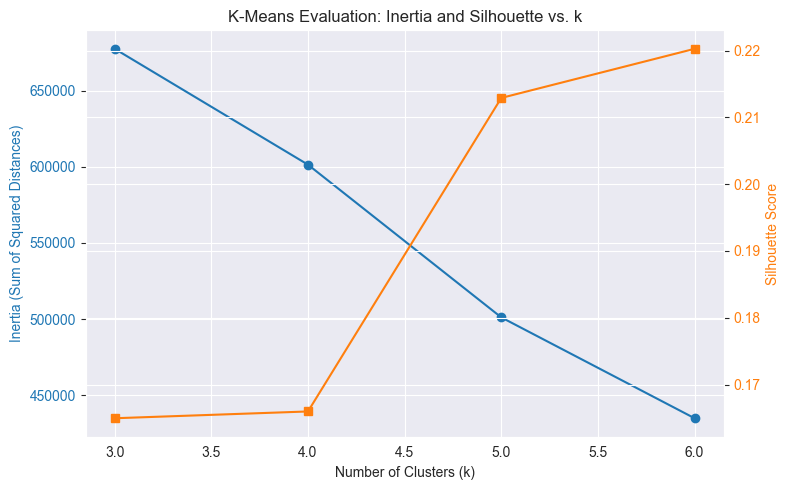

In [8]:
# INTERNAL INDICES VISUALIZATION (Elbow & Silhouette)

inertia_vals = [res['Inertia'] for res in kmeans_results]
sil_vals = [res['Silhouette'] for res in kmeans_results]

fig, ax1 = plt.subplots(figsize=(8, 5))

# Plot Inertia (Left Y-axis)
color = 'tab:blue'
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Sum of Squared Distances)', color=color)
ax1.plot(k_range, inertia_vals, marker='o', color=color, label='Inertia')
ax1.tick_params(axis='y', labelcolor=color)

# Plot Silhouette (Right Y-axis)
ax2 = ax1.twinx()
color = 'tab:orange'
ax2.set_ylabel('Silhouette Score', color=color)
ax2.plot(k_range, sil_vals, marker='s', color=color, label='Silhouette')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('K-Means Evaluation: Inertia and Silhouette vs. k')
fig.tight_layout()
plt.show()



In [9]:
# INITIAL INTERPRETATION OF CLUSTER PROFILES

selected_k = 5

best_result = comparison_results[selected_variant]['k_results'][selected_k]
best_labels = best_result['labels']

df_profiling = df_clean.copy()
df_profiling['Cluster'] = best_labels

# Calculate the mean of the original numerical variables (unscaled) per Cluster
num_features = ['adults', 'children', 'babies', 'stays_in_weekend_nights', 'stays_in_week_nights']
cluster_profiles = df_profiling.groupby('Cluster')[num_features].mean().round(2)

# Add the count of each cluster
cluster_profiles['Size (%)'] = (df_profiling['Cluster'].value_counts(normalize=True) * 100).round(1)

print(cluster_profiles)


         adults  children  babies  stays_in_weekend_nights  \
Cluster                                                      
0          2.07      0.00    0.00                     0.72   
1          0.99      0.00    0.00                     0.53   
2          1.99      0.23    1.02                     1.16   
3          1.96      1.46    0.00                     1.04   
4          1.96      0.01    0.00                     2.31   

         stays_in_week_nights  Size (%)  
Cluster                                  
0                        2.00      61.1  
1                        1.69      17.8  
2                        3.01       0.8  
3                        2.67       6.8  
4                        5.68      13.5  


### Do the clusters answer RQ1?

The clustering result (k=5) creates five distinct segments with different stay/group patterns:

- **Cluster 0 (61.1% of bookings)**  
  - Moderate group size (≈2.07 adults, 0 children, 0 babies)
  - Short stays (≈0.72 weekend nights, 2.0 week nights)  
   likely **couple short-stay**.

- **Cluster 1 (17.8% of bookings)**  
  - Very small groups (≈1.0 adult, no children, no babies)
  - Very short stays (≈0.53 weekend nights, 1.7 week nights)  
   likely **solo short stays**.

- **Cluster 2 (0.8% of bookings)**  
  - Mixed family/party bookings (≈1.99 adults, 0.23 children, 1.02 babies)
  - Moderate stay length (≈1.16 weekend nights, 3.0 week nights)  
   likely **small families with infants**.

- **Cluster 3 (6.8% of bookings)**  
  - Family stays without infants (≈1.96 adults, 1.46 children, 0 babies)
  - Moderate stay length (≈1.04 weekend nights, 2.7 week nights)  
   likely **shorter family stays with older children**.

- **Cluster 4 (13.5% of bookings)**  
  - Adult-oriented longer stays (≈1.96 adults, almost no children/babies)
  - Longer duration (≈2.31 weekend nights, 5.7 week nights)  
   likely **extended leisure stays for adult couples**.

**Conclusion:**  
Yes—distinct clusters emerge that align with RQ1. The segments differentiate shorter-stay adult bookings, solo short trips, family bookings with infants, family bookings with older children, and longer-stay leisure/adult group bookings. This supports the idea that natural guest segments exist based on group composition and weekend/weekday stay patterns.

# iK-Means Evaluation

In [14]:
from numpy.typing import NDArray

FloatArray = NDArray[np.float64]

class APCluster:
    indices: list[int]
    centroid_raw: FloatArray
    centroid_std: FloatArray
    size: int
    scatter_pct: float

In [12]:
# Function that computes µ, r (range scaling, zero-ranges → 1), and total scatter D.

def compute_feature_statistics(
    X: FloatArray,
    use_unit_ranges: bool = False,
) -> tuple[FloatArray, FloatArray, float]:

    X = np.asarray(X, dtype=np.float64)
    mean = X.mean(axis=0)

    if use_unit_ranges:
        scales = np.ones(X.shape[1], dtype=np.float64)
    else:
        scales = X.max(axis=0) - X.min(axis=0)
        scales[scales == 0] = 1

    Y = (X - mean) / scales
    total_scatter = float(np.sum(Y**2))

    return mean, scales, total_scatter

# Function that computes δ (squared distances) for a set of indices
def normalized_squared_distances(
    X: FloatArray,
    indices: list[int],
    scales: FloatArray,
    reference: FloatArray,
) -> FloatArray:

    X = np.asarray(X, dtype=np.float64)
    diff = (X[indices] - reference) / scales

    return np.sum(diff**2, axis=1)


# Function that returns the component-wise mean of the selected rows
def cluster_centroid(
    X: FloatArray,
    indices: list[int],
) -> FloatArray:

    return np.asarray(X, dtype=np.float64)[indices].mean(axis=0)

In [13]:
# Function that returns the subset of "indices" that are strictly closer to "a" than to "b"
def separate_cluster(
    X: FloatArray,
    indices: list[int],
    scales: FloatArray,
    a: FloatArray,
    b: FloatArray,
) -> list[int]:

    dist_a = normalized_squared_distances(X, indices, scales, a)
    dist_b = normalized_squared_distances(X, indices, scales, b)
    mask = dist_a < dist_b
    return sorted(np.array(indices)[mask].tolist())

# Function that extracts one anomalous cluster from the residual set "indices"
def extract_anomalous_cluster(
    X: FloatArray,
    indices: list[int],
    scales: FloatArray,
    mean: FloatArray,
    initial_centroid: FloatArray,
    seed_index: int,
    tol: float = 1e-12,
    max_iter: int = 10_000,
) -> tuple[list[int], FloatArray]:

    X = np.asarray(X, dtype=np.float64)
    c = initial_centroid.copy()
    S_prev: list[int] = []

    for _ in range(max_iter):
        # Assign: rows strictly closer to c than to µ
        S = separate_cluster(X, indices, scales, c, mean)

        # Numerical safeguard: if nothing is closer to c, keep just the seed
        if len(S) == 0:
            S = [seed_index]

        c_new = cluster_centroid(X, S)

        # Check membership convergence
        if S == S_prev:
            return S, c_new

        # Check centroid convergence
        if np.linalg.norm(c_new - c) <= tol:
            return S, c_new

        c = c_new
        S_prev = S
    return S, c

In [15]:
# Function that initializes iK-Means
def ikmeans_initialize(
    X: FloatArray,
    min_cluster_size: int,
    tol: float = 1e-12,
    max_iter: int = 10_000,
    use_unit_ranges: bool = False,
) -> tuple[list[APCluster], FloatArray]:

    X = np.asarray(X, dtype=np.float64)
    n = X.shape[0]

    # grand mean, scales, total scatter
    mean, scales, D = compute_feature_statistics(X, use_unit_ranges = use_unit_ranges)

    # initialise residual index set
    remains: list[int] = list(range(n))
    ap_clusters: list[APCluster] = []

    while remains:
        # Select seed = farthest remaining point from µ
        dist_to_mean = normalized_squared_distances(X, remains, scales, mean)
        q_local = int(np.argmax(dist_to_mean))   # position within remains
        q = remains[q_local]                      # actual row index in X
        seed = X[q].copy()

        # extract one anomalous cluster
        S, c = extract_anomalous_cluster(
            X, remains, scales, mean, seed, q, tol=tol, max_iter=max_iter
        )

        # standardise centroid
        z = (c - mean) / scales

        # scatter percentage
        if D > 0:
            scatter_pct = 100.0 * len(S) * float(np.sum(z ** 2)) / D
        else:
            scatter_pct = 0.0

        # store record
        record = APCluster(
            indices=S,
            centroid_raw=c,
            centroid_std=z,
            size=len(S),
            scatter_pct=scatter_pct,
        )
        ap_clusters.append(record)

        # remove extracted indices from residual set
        S_set = set(S)
        remains = [i for i in remains if i not in S_set]

    # filter by minimum size
    retained = [rec for rec in ap_clusters if rec.size >= min_cluster_size]
    if not retained:
        raise ValueError(
            f"No anomalous cluster satisfies the minimum size threshold "
            f"(min_cluster_size={min_cluster_size}). "
            f"Largest cluster found has size "
            f"{max(rec.size for rec in ap_clusters)}."
        )

    # stack standardised centroids → init matrix of shape (k, d)
    init_centroids = np.vstack([rec.centroid_std for rec in retained])

    return ap_clusters, init_centroids

# Task 2 - Alternative Clustering Family

## 2.1 Development